# Example 12 - Historical Simulation VaR SWIG Workflow

This notebook runs the public historical simulation VaR workflow through
`OREApp`. It demonstrates full-revaluation and sensitivity-based P&L,
expected shortfall, trade P&L, risk-factor P&L, explicit analytic downcast,
and analytic-owned report retrieval.

All MarketRisk inputs used below are versioned in this example's `Input`
directory; the notebook has no runtime dependency on another example.

## 1 - Environment setup

In [1]:
from pathlib import Path

import ORE

base_dir = Path.cwd()
input_dir = base_dir / "Input"
output_dir = base_dir / "Output"
output_dir.mkdir(parents=True, exist_ok=True)

print("HistoricalSimulationVarAnalytic:", hasattr(ORE, "HistoricalSimulationVarAnalytic"))
print("HistoricalSimulationVarCalculator:", hasattr(ORE, "HistoricalSimulationVarCalculator"))

HistoricalSimulationVarAnalytic: True
HistoricalSimulationVarCalculator: True


## 2 - Configure the public workflow

The two runs differ only in whether both sensitivity prerequisites are supplied.
Providing both selects sensitivity-based P&L; omitting both selects full
revaluation.

In [2]:
def read_xml(name):
    return (input_dir / name).read_text(encoding="utf-8")


def historical_var_inputs(use_sensitivity):
    mode_output_dir = output_dir / ("sensitivity" if use_sensitivity else "full_revaluation")
    mode_output_dir.mkdir(parents=True, exist_ok=True)
    inputs = ORE.InputParameters()
    inputs.setAsOfDate("2019-12-30")
    inputs.setResultsPath(str(mode_output_dir))
    inputs.setAllFixings(True)
    inputs.setEntireMarket(True)
    inputs.setBaseCurrency("EUR")
    inputs.setCurveConfigs(read_xml("curveconfig.xml"))
    inputs.setConventions(read_xml("conventions.xml"))
    inputs.setPricingEngine(read_xml("pricingengine.xml"))
    inputs.setTodaysMarketParams(read_xml("todaysmarket.xml"))
    inputs.setPortfolio(read_xml("portfolio.xml"))
    for context in ("lgmcalibration", "fxcalibration", "pricing", "simulation", "sensitivity"):
        inputs.setMarketConfig("default", context)
    inputs.insertAnalytic("HISTSIM_VAR")
    inputs.setHistVarSimMarketParamsFromFile(str(input_dir / "simulation.xml"))
    inputs.setParameter("historicalSimulationVar", "historicalScenarioFile", str(input_dir / "scenarios.csv"))
    inputs.setParameter("historicalSimulationVar", "historicalPeriod", "2017-01-17,2019-12-30")
    inputs.setParameter("historicalSimulationVar", "mporDays", "10")
    inputs.setParameter("historicalSimulationVar", "mporCalendar", "USD")
    inputs.setParameter("historicalSimulationVar", "mporOverlappingPeriods", "true")
    inputs.setParameter("historicalSimulationVar", "quantiles", "0.01,0.05,0.95,0.99")
    inputs.setIncludeExpectedShortfall(True)
    inputs.setTradePnl(True)
    inputs.setRiskFactorBreakdown(True)
    if use_sensitivity:
        inputs.setParameter("historicalSimulationVar", "sensitivityInputFile", str(input_dir / "sensitivity.csv"))
        inputs.setParameter("historicalSimulationVar", "sensitivityConfigFile", str(input_dir / "sensitivity.xml"))

    return inputs

## 3 - Run both P&L modes and inspect analytic-owned reports

In [3]:
def run_historical_var(name, use_sensitivity):
    log_file = output_dir / ("sensitivity" if use_sensitivity else "full_revaluation") / "log.txt"
    app = ORE.OREApp(historical_var_inputs(use_sensitivity), str(log_file))
    market_data = (input_dir / "market.txt").read_text(encoding="utf-8").splitlines()
    fixing_data = (input_dir / "fixings.txt").read_text(encoding="utf-8").splitlines()
    app.run(market_data, fixing_data)

    analytic = ORE.asHistoricalSimulationVarAnalytic(app.getAnalytic("HISTSIM_VAR"))
    reports = {
        "var": analytic.getReport("HISTSIM_VAR", "var"),
        "historical_PnL": analytic.getReport("HISTSIM_VAR", "historical_PnL"),
        "riskFactor_PnL": analytic.getReport("HISTSIM_VAR", "riskFactor_PnL"),
    }
    shape = {key: (report.rows(), report.columns()) for key, report in reports.items()}
    expected_columns = {"var": 11, "historical_PnL": 6, "riskFactor_PnL": 5}
    for key, columns in expected_columns.items():
        assert reports[key].rows() > 0
        assert reports[key].columns() == columns
    print(name, shape)
    return reports


full_revaluation_reports = run_historical_var("full revaluation", False)
sensitivity_reports = run_historical_var("sensitivity based", True)

full revaluation {'var': (6, 11), 'historical_PnL': (8580, 6), 'riskFactor_PnL': (29873, 5)}


sensitivity based {'var': (6, 11), 'historical_PnL': (8580, 6), 'riskFactor_PnL': (29873, 5)}


## 4 - Inspect trade-level P&L

With `setTradePnl(True)`, `historical_PnL` contains rows for each trade,
historical scenario, risk class, and risk type. ORE labels the first column
`Portfolio`, but it contains the trade ID in this mode. The tables below
retain every raw trade P&L row.

## 5 - Plot aggregate trade P&L and 99% VaR

The charts sum the `All`/`All` trade rows by scenario, then calculate the 99%
VaR and expected shortfall directly from those aggregate P&Ls.

,TradeId,RiskClass,RiskType,PLDate1,PLDate2,PLAmount
0,FXFWD_EURUSD_10Y,All,All,2016-12-30,2017-01-17,4554.952037
1,XCCY_Swap_EUR_USD,All,All,2016-12-30,2017-01-17,-554263.940630
2,FXFWD_EURUSD_10Y,All,All,2017-01-03,2017-01-18,17662.009322
3,XCCY_Swap_EUR_USD,All,All,2017-01-03,2017-01-18,-657764.805777
4,FXFWD_EURUSD_10Y,All,All,2017-01-04,2017-01-19,16679.287924


,RiskFactor,TradeId,PLDate1,PLDate2,PLAmount
0,DiscountCurve/EUR/0,FXFWD_EURUSD_10Y,2016-12-30,2017-01-17,-0.338201
1,DiscountCurve/EUR/0,XCCY_Swap_EUR_USD,2016-12-30,2017-01-17,12.373787
2,DiscountCurve/EUR/1,XCCY_Swap_EUR_USD,2016-12-30,2017-01-17,0.013080
3,DiscountCurve/EUR/2,XCCY_Swap_EUR_USD,2016-12-30,2017-01-17,0.646293
4,DiscountCurve/EUR/3,XCCY_Swap_EUR_USD,2016-12-30,2017-01-17,3.706750


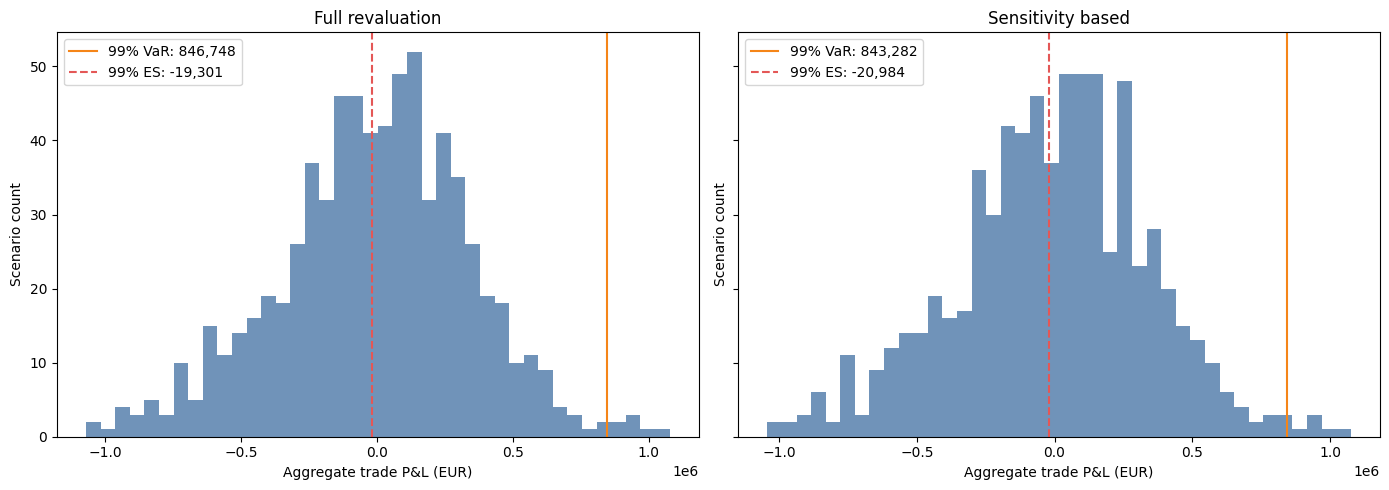

In [4]:
import matplotlib.pyplot as plt
import pandas as pd


def trade_level_pnls(report):
    plain = ORE.PlainInMemoryReport(report)
    return pd.DataFrame(
        {
            "TradeId": plain.dataAsString(0),
            "RiskClass": plain.dataAsString(1),
            "RiskType": plain.dataAsString(2),
            "PLDate1": [date.ISO() for date in plain.dataAsDate(3)],
            "PLDate2": [date.ISO() for date in plain.dataAsDate(4)],
            "PLAmount": plain.dataAsReal(5),
        }
    )


def risk_factor_pnls(report):
    plain = ORE.PlainInMemoryReport(report)
    return pd.DataFrame(
        {
            "RiskFactor": plain.dataAsString(0),
            "TradeId": plain.dataAsString(1),
            "PLDate1": [date.ISO() for date in plain.dataAsDate(2)],
            "PLDate2": [date.ISO() for date in plain.dataAsDate(3)],
            "PLAmount": plain.dataAsReal(4),
        }
    )


full_revaluation_trade_pnls = trade_level_pnls(full_revaluation_reports["historical_PnL"])
sensitivity_trade_pnls = trade_level_pnls(sensitivity_reports["historical_PnL"])
full_revaluation_risk_factor_pnls = risk_factor_pnls(full_revaluation_reports["riskFactor_PnL"])
sensitivity_risk_factor_pnls = risk_factor_pnls(sensitivity_reports["riskFactor_PnL"])
assert not full_revaluation_trade_pnls.empty
assert not full_revaluation_risk_factor_pnls.empty
display(full_revaluation_trade_pnls.head(), full_revaluation_risk_factor_pnls.head())


def aggregate_trade_pnls(report):
    plain = ORE.PlainInMemoryReport(report)
    pnls_by_scenario = {}
    for start, end, risk_class, risk_type, pnl in zip(
        plain.dataAsDate(3),
        plain.dataAsDate(4),
        plain.dataAsString(1),
        plain.dataAsString(2),
        plain.dataAsReal(5),
    ):
        if risk_class == "All" and risk_type == "All":
            key = (str(start), str(end))
            pnls_by_scenario[key] = pnls_by_scenario.get(key, 0.0) + pnl
    return list(pnls_by_scenario.values())


def plot_pnl_distribution(axis, name, reports):
    pnls = aggregate_trade_pnls(reports["historical_PnL"])
    calculator = ORE.HistoricalSimulationVarCalculator(pnls)
    value_at_risk = calculator.var(0.99)
    expected_shortfall = calculator.expectedShortfall(0.99)

    axis.hist(pnls, bins=40, color="#4c78a8", alpha=0.8)
    axis.axvline(value_at_risk, color="#f58518", label=f"99% VaR: {value_at_risk:,.0f}")
    axis.axvline(expected_shortfall, color="#e45756", linestyle="--", label=f"99% ES: {expected_shortfall:,.0f}")
    axis.set_title(name)
    axis.set_xlabel("Aggregate trade P&L (EUR)")
    axis.set_ylabel("Scenario count")
    axis.legend()
    return value_at_risk, expected_shortfall


figure, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
full_revaluation_var, full_revaluation_es = plot_pnl_distribution(
    axes[0], "Full revaluation", full_revaluation_reports
)
sensitivity_var, sensitivity_es = plot_pnl_distribution(
    axes[1], "Sensitivity based", sensitivity_reports
)
figure.tight_layout()
plt.show()

## 5 - Calculate directly from a P&L vector

The direct calculator retains the C++ tail-P&L convention. `isCall=False`
reverses the supplied P&L signs before calculating the quantile.

In [5]:
calculator = ORE.HistoricalSimulationVarCalculator([float(value) for value in range(1, 1002)])
direct_results = {
    "var": calculator.var(0.99),
    "expected_shortfall": calculator.expectedShortfall(0.99),
    "reversed_var": calculator.var(0.99, False),
}
assert direct_results["var"] > 0.0
assert direct_results["reversed_var"] < 0.0
direct_results

{'var': 991.0, 'expected_shortfall': 496.0, 'reversed_var': -11.0}